# Sales Performance Analysis

## Objective
This project analyzes sales transaction data to identify sales trends, top-performing product lines, strongest markets, and deal size patterns.

## Tools Used
- Python
- Pandas
- Matplotlib
- Jupyter Notebook

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sales_data.csv", encoding="latin1")

In [25]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())

(2823, 25)
Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE',
       'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE',
       'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME',
       'DEALSIZE'],
      dtype='object')
ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME 

In [26]:
df = df.drop_duplicates()

In [27]:
print(df.shape)

(2823, 25)


In [28]:
print(df.describe())

        ORDERNUMBER  QUANTITYORDERED    PRICEEACH  ORDERLINENUMBER  \
count   2823.000000      2823.000000  2823.000000      2823.000000   
mean   10258.725115        35.092809    83.658544         6.466171   
std       92.085478         9.741443    20.174277         4.225841   
min    10100.000000         6.000000    26.880000         1.000000   
25%    10180.000000        27.000000    68.860000         3.000000   
50%    10262.000000        35.000000    95.700000         6.000000   
75%    10333.500000        43.000000   100.000000         9.000000   
max    10425.000000        97.000000   100.000000        18.000000   

              SALES       QTR_ID     MONTH_ID     YEAR_ID         MSRP  
count   2823.000000  2823.000000  2823.000000  2823.00000  2823.000000  
mean    3553.889072     2.717676     7.092455  2003.81509   100.715551  
std     1841.865106     1.203878     3.656633     0.69967    40.187912  
min      482.130000     1.000000     1.000000  2003.00000    33.000000  
25% 

In [29]:
print(df.columns.tolist())

['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE', 'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE', 'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE']


In [30]:
df_clean = df[['ORDERDATE', 'QUANTITYORDERED', 'SALES', 'PRODUCTLINE', 'COUNTRY', 'DEALSIZE']].copy()
print(df_clean.head())

         ORDERDATE  QUANTITYORDERED    SALES  PRODUCTLINE COUNTRY DEALSIZE
0   2/24/2003 0:00               30  2871.00  Motorcycles     USA    Small
1    5/7/2003 0:00               34  2765.90  Motorcycles  France    Small
2    7/1/2003 0:00               41  3884.34  Motorcycles  France   Medium
3   8/25/2003 0:00               45  3746.70  Motorcycles     USA   Medium
4  10/10/2003 0:00               49  5205.27  Motorcycles     USA   Medium


In [31]:
df_clean = df[['ORDERDATE', 'QUANTITYORDERED', 'SALES', 'PRODUCTLINE', 'COUNTRY', 'DEALSIZE']].copy()

df_clean['ORDERDATE'] = pd.to_datetime(df_clean['ORDERDATE'])

print(df_clean.head())

   ORDERDATE  QUANTITYORDERED    SALES  PRODUCTLINE COUNTRY DEALSIZE
0 2003-02-24               30  2871.00  Motorcycles     USA    Small
1 2003-05-07               34  2765.90  Motorcycles  France    Small
2 2003-07-01               41  3884.34  Motorcycles  France   Medium
3 2003-08-25               45  3746.70  Motorcycles     USA   Medium
4 2003-10-10               49  5205.27  Motorcycles     USA   Medium


In [32]:
import matplotlib.pyplot as plt

df_clean['MONTH'] = df_clean['ORDERDATE'].dt.to_period('M')

monthly_sales = df_clean.groupby('MONTH')['SALES'].sum()

print(monthly_sales)

MONTH
2003-01     129753.60
2003-02     140836.19
2003-03     174504.90
2003-04     201609.55
2003-05     192673.11
2003-06     168082.56
2003-07     187731.88
2003-08     197809.30
2003-09     263973.36
2003-10     568290.97
2003-11    1029837.66
2003-12     261876.46
2004-01     316577.42
2004-02     311419.53
2004-03     205733.73
2004-04     206148.12
2004-05     273438.39
2004-06     286674.22
2004-07     327144.09
2004-08     461501.27
2004-09     320750.91
2004-10     552924.25
2004-11    1089048.01
2004-12     372802.66
2005-01     339543.42
2005-02     358186.18
2005-03     374262.76
2005-04     261633.29
2005-05     457861.06
Freq: M, Name: SALES, dtype: float64


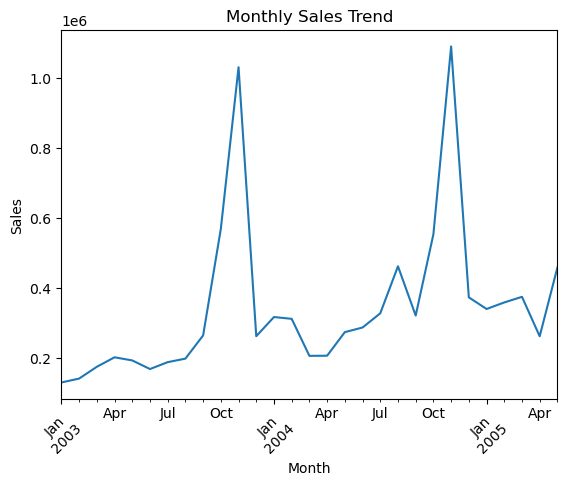

In [33]:
monthly_sales.plot(kind='line')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.show()

In [34]:
productline_sales = df_clean.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)

print(productline_sales)

PRODUCTLINE
Classic Cars        3919615.66
Vintage Cars        1903150.84
Motorcycles         1166388.34
Trucks and Buses    1127789.84
Planes               975003.57
Ships                714437.13
Trains               226243.47
Name: SALES, dtype: float64


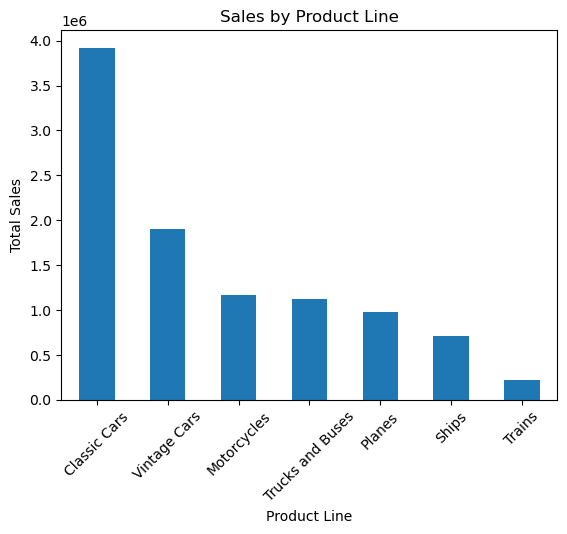

In [35]:
productline_sales.plot(kind='bar')

plt.title("Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

In [36]:
country_sales = df_clean.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False)

print(country_sales)

COUNTRY
USA            3627982.83
Spain          1215686.92
France         1110916.52
Australia       630623.10
UK              478880.46
Italy           374674.31
Finland         329581.91
Norway          307463.70
Singapore       288488.41
Denmark         245637.15
Canada          224078.56
Germany         220472.09
Sweden          210014.21
Austria         202062.53
Japan           188167.81
Switzerland     117713.56
Belgium         108412.62
Philippines      94015.73
Ireland          57756.43
Name: SALES, dtype: float64


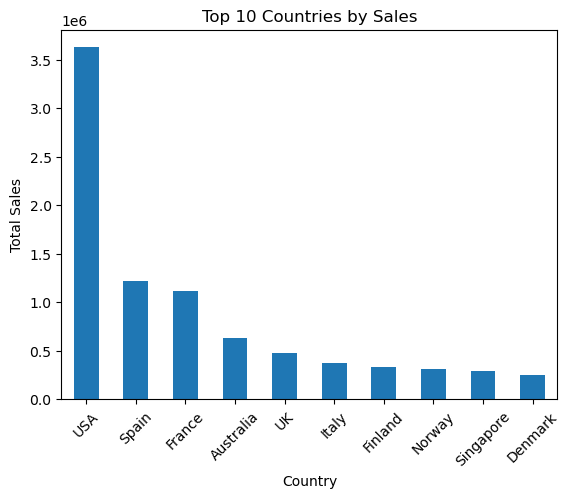

In [37]:
top_10_countries = country_sales.head(10)

top_10_countries.plot(kind='bar')

plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

In [38]:
deal_sales = df_clean.groupby('DEALSIZE')['SALES'].sum().sort_values(ascending=False)

print(deal_sales)

DEALSIZE
Medium    6087432.24
Small     2643077.35
Large     1302119.26
Name: SALES, dtype: float64


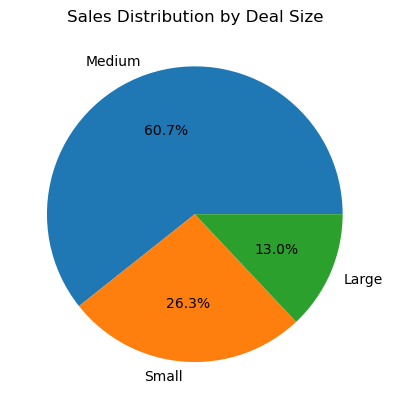

In [39]:
deal_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title("Sales Distribution by Deal Size")
plt.ylabel("")

plt.show()

### Insight: Deal Size Analysis

Medium-sized deals generated the highest total sales in the dataset. This shows that most revenue came from mid-sized customer purchases. The business can focus on maintaining medium-sized deals while also finding ways to increase large deal opportunities.

In [40]:
deal_count = df_clean['DEALSIZE'].value_counts()

print(deal_count)

DEALSIZE
Medium    1384
Small     1282
Large      157
Name: count, dtype: int64


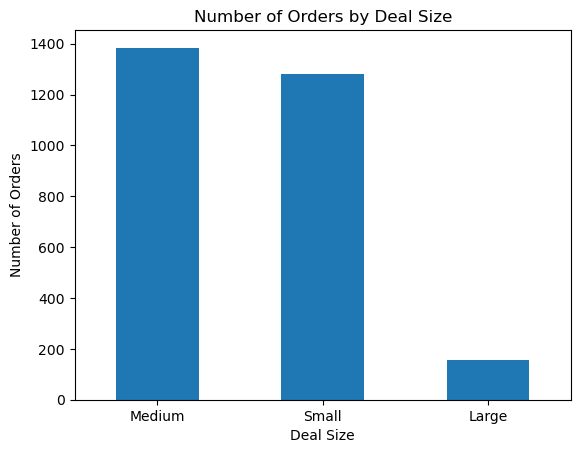

In [41]:
deal_count.plot(kind='bar')

plt.title("Number of Orders by Deal Size")
plt.xlabel("Deal Size")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)

plt.show()

In [42]:
top_productline = productline_sales.idxmax()
top_productline_sales = productline_sales.max()

top_country = country_sales.idxmax()
top_country_sales = country_sales.max()

top_dealsize = deal_sales.idxmax()
top_dealsize_sales = deal_sales.max()

most_common_dealsize = deal_count.idxmax()
most_common_dealsize_count = deal_count.max()

print("INSIGHTS SUMMARY")
print("----------------")
print(f"1. The highest revenue-generating product line is {top_productline}, with total sales of ${top_productline_sales:,.2f}.")
print(f"2. The country with the highest sales is {top_country}, generating ${top_country_sales:,.2f}.")
print(f"3. The deal size contributing the most revenue is {top_dealsize}, with total sales of ${top_dealsize_sales:,.2f}.")
print(f"4. The most common deal size is {most_common_dealsize}, appearing in {most_common_dealsize_count} orders.")
print("5. Monthly sales trend analysis helps identify changes in sales performance over time.")

INSIGHTS SUMMARY
----------------
1. The highest revenue-generating product line is Classic Cars, with total sales of $3,919,615.66.
2. The country with the highest sales is USA, generating $3,627,982.83.
3. The deal size contributing the most revenue is Medium, with total sales of $6,087,432.24.
4. The most common deal size is Medium, appearing in 1384 orders.
5. Monthly sales trend analysis helps identify changes in sales performance over time.



### Insight: Product Line Performance

The product line with the highest total sales was Classic Cars. This shows that Classic Cars contributed the most revenue compared to other product categories. The business can focus more on high-performing product lines while also reviewing lower-performing categories for improvement.

### Insight: Country-wise Sales Performance

USA had the highest total sales, generating $3,627,982.83. This shows that USA was the strongest market in the dataset. Other countries had lower sales compared to USA, so the business can focus on maintaining strong sales in USA while exploring growth opportunities in lower-performing countries.

## Final Insights Summary

- Classic Cars generated the highest total sales, making it the strongest product line.
- USA was the top-performing country by revenue, showing it was the strongest market.
- Medium-sized deals contributed the highest sales, meaning mid-sized purchases were the main revenue driver.
- Sales performance changed across months, which can help the business identify strong and weak sales periods.

## Business Recommendation

The business should continue focusing on high-performing product lines like Classic Cars and strong markets like USA. It should also look for ways to increase large deals while maintaining medium-sized customer purchases.

In [43]:
df_clean.to_csv("cleaned_sales_data.csv", index=False)